In [39]:
import pandas as pd
import numpy as np
import spacy
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import textstat
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.util import ngrams
from scipy.stats import entropy
from textblob import TextBlob

from collections import Counter
from os import walk
import os
from pathlib import Path
from tqdm import tqdm


In [40]:
#!python -m spacy download en_core_web_sm

In [41]:
nlp = spacy.load("en_core_web_sm")

In [42]:
LLMS = ['bloomz', 'chatgpt', 'cohere', 'davinci', 'human']

In [43]:
def extract_stylometric_features(text):
    if not text.strip():
        return {}

    doc = nlp(text)

    # Tokenization
    words = [token.text for token in doc if token.is_alpha]
    sentences = list(doc.sents)
    
    # ---------------- 1. LEXICAL FEATURES ----------------
    num_words = len(words)
    num_sentences = len(sentences)
    avg_word_length = np.mean([len(word) for word in words]) if words else 0
    avg_sentence_length = num_words / num_sentences if num_sentences > 0 else 0
    unique_word_ratio = len(set(words)) / num_words if num_words else 0  # Vocabulary richness

    # Hapax Legomena (words appearing once)
    word_freq = Counter(words)
    hapax_legomena_ratio = sum(1 for v in word_freq.values() if v == 1) / num_words if num_words else 0

    # Bigram and Trigram Entropy (Measures Predictability)
    bigrams = list(ngrams(words, 2))
    trigrams = list(ngrams(words, 3))
    bigram_entropy = entropy(list(Counter(bigrams).values())) if bigrams else 0
    trigram_entropy = entropy(list(Counter(trigrams).values())) if trigrams else 0

    # ---------------- 2. SYNTACTIC FEATURES ----------------
    pos_counts = Counter(token.pos_ for token in doc)
    punctuation_count = sum(1 for token in doc if token.is_punct)
    avg_commas_per_sentence = punctuation_count / num_sentences if num_sentences else 0

    # POS Tag Ratios
    noun_ratio = pos_counts["NOUN"] / num_words if num_words else 0
    verb_ratio = pos_counts["VERB"] / num_words if num_words else 0
    adj_ratio = pos_counts["ADJ"] / num_words if num_words else 0
    adv_ratio = pos_counts["ADV"] / num_words if num_words else 0

    # ---------------- 3. STRUCTURAL FEATURES ----------------
    num_paragraphs = text.count("\n") + 1
    avg_sentence_per_paragraph = num_sentences / num_paragraphs if num_paragraphs else 0

    # ---------------- 4. SEMANTIC FEATURES ----------------
    # Sentiment Scores (requires installation of Vader or TextBlob)
    from textblob import TextBlob
    sentiment = TextBlob(text).sentiment
    polarity = sentiment.polarity  # -1 (negative) to +1 (positive)
    subjectivity = sentiment.subjectivity  # 0 (objective) to 1 (subjective)

    # ---------------- 5. PSYCHOLINGUISTIC FEATURES ----------------
    flesch_reading_ease = textstat.flesch_reading_ease(text) if text.strip() else 0
    smog_index = textstat.smog_index(text) if text.strip() else 0
    avg_syllables_per_word = textstat.syllable_count(text) / num_words if num_words else 0

    # ---------------- 6. CHARACTER-LEVEL FEATURES ----------------
    num_chars = len(text)
    digit_count = sum(c.isdigit() for c in text)
    uppercase_ratio = sum(1 for c in text if c.isupper()) / num_chars if num_chars else 0
    special_char_ratio = sum(1 for c in text if not c.isalnum() and not c.isspace()) / num_chars if num_chars else 0

    return {
        #"num_words": num_words,
        #"num_sentences": num_sentences,
        "avg_word_length": avg_word_length,
        "avg_sentence_length": avg_sentence_length,
        "unique_word_ratio": unique_word_ratio,
        "hapax_legomena_ratio": hapax_legomena_ratio,
        "bigram_entropy": bigram_entropy,
        "trigram_entropy": trigram_entropy,
        "punctuation_count": punctuation_count,
        "avg_commas_per_sentence": avg_commas_per_sentence,
        "noun_ratio": noun_ratio,
        "verb_ratio": verb_ratio,
        "adj_ratio": adj_ratio,
        "adv_ratio": adv_ratio,
        #"num_paragraphs": num_paragraphs,
        "avg_sentence_per_paragraph": avg_sentence_per_paragraph,
        "polarity": polarity,
        "subjectivity": subjectivity,
        "flesch_reading_ease": flesch_reading_ease,
        "smog_index": smog_index,
        "avg_syllables_per_word": avg_syllables_per_word,
        #"num_chars": num_chars,
        "digit_count": digit_count,
        "uppercase_ratio": uppercase_ratio,
        "special_char_ratio": special_char_ratio
    }

In [44]:
df = pd.DataFrame(columns=['text', 'is_llm', 'domain', 'dataset_name'])

dir_path, dir_names, file_names = next(walk('../../data/raw/m4-unified'))

for dir in dir_names:
    dataset_folder_path, _, dataset_names = next(walk(os.path.join(dir_path, dir)))
    for dataset_name in dataset_names:
        temp_df = pd.read_json(path_or_buf=f'{dataset_folder_path}/{dataset_name}', lines=True)
        temp_df['domain'] = dir
        temp_df['dataset_name'] = Path(dataset_name).stem
        temp_df['author'] = Path(dataset_name).stem.split('_')[1]

        if Path(dataset_name).stem.split('_')[1].lower() not in LLMS:
          continue
        temp_df['is_llm'] = 0 if 'human' in dataset_name else 1
        print(dataset_name, 0 if 'human' in dataset_name else 1 )
        df = pd.concat([df, temp_df], ignore_index=True)

arxiv_bloomz.jsonl 1
arxiv_chatGPT.jsonl 1
arxiv_cohere.jsonl 1
arxiv_davinci.jsonl 1
arxiv_human.jsonl 0
reddit_bloomz.jsonl 1
reddit_chatGPT.jsonl 1
reddit_cohere.jsonl 1
reddit_davinci.jsonl 1
reddit_human.jsonl 0
wikihow_bloomz.jsonl 1
wikihow_chatGPT.jsonl 1
wikihow_cohere.jsonl 1
wikihow_davinci.jsonl 1
wikihow_human.jsonl 0
wikipedia_bloomz.jsonl 1
wikipedia_chatGPT.jsonl 1
wikipedia_cohere.jsonl 1
wikipedia_davinci.jsonl 1
wikipedia_human.jsonl 0


In [45]:
sampled_df = df
sampled_df[sampled_df['is_llm'] == 0]

,text,is_llm,domain,dataset_name,author
12000,A rather non-standard quantum representation...,0,arxiv,arxiv_human,human
12001,We discuss the results from the combined IRA...,0,arxiv,arxiv_human,human
12002,Results from spectroscopic observations of t...,0,arxiv,arxiv_human,human
12003,We present Lie group integrators for nonline...,0,arxiv,arxiv_human,human
12004,"The very nature of the solar chromosphere, i...",0,arxiv,arxiv_human,human
...,...,...,...,...,...
59321,Adolf Fredrik Church () is a church in central...,0,wikipedia,wikipedia_human,human
59322,I've Been Doin' Some Thinkin' is an album by A...,0,wikipedia,wikipedia_human,human
59323,Michele Samantha Yi Wen Lean ) (born 1 Septemb...,0,wikipedia,wikipedia_human,human
59324,The Speaker of the Provincial Assembly of Punj...,0,wikipedia,wikipedia_human,human


In [46]:
tqdm.pandas()
# Extract features for all texts
#feature_dicts = sampled_df["text"].progress_apply(extract_stylometric_features)
#feature_df = pd.DataFrame(feature_dicts.tolist())  # Convert list of dicts to DataFrame
#feature_df.to_csv('../../data/stylometry/m4-initial-20-features.csv')
feature_df = pd.read_csv('../../data/stylometry/m4-initial-20-features.csv')


In [47]:
bino_results_df = pd.read_csv('../../data/binoculars/42rand_state-1000-samples/combined.csv')

In [48]:
data = pd.concat([feature_df.reset_index(), sampled_df["is_llm"].reset_index()], axis=1)
data.drop(columns=["index","Unnamed: 0", "num_words", "num_sentences", "num_paragraphs", "num_chars"], inplace=True)
data

,avg_word_length,avg_sentence_length,unique_word_ratio,hapax_legomena_ratio,bigram_entropy,trigram_entropy,punctuation_count,avg_commas_per_sentence,noun_ratio,verb_ratio,...,avg_sentence_per_paragraph,polarity,subjectivity,flesch_reading_ease,smog_index,avg_syllables_per_word,digit_count,uppercase_ratio,special_char_ratio,is_llm
0,5.222222,23.625000,0.693122,0.571429,5.112893,5.154177,19.0,2.375000,0.328042,0.116402,...,8.000000,-0.021667,0.306667,39.37,15.9,1.719577,0.0,0.011589,0.018212,1
1,5.382353,28.333333,0.794118,0.676471,5.093991,5.123964,19.0,3.166667,0.235294,0.135294,...,3.000000,0.033335,0.442373,32.63,15.7,1.835294,16.0,0.019315,0.019315,1
2,4.833333,16.500000,0.750000,0.598485,4.811703,4.846207,27.0,3.375000,0.219697,0.143939,...,8.000000,0.093939,0.374242,53.10,12.8,1.765152,60.0,0.059091,0.030682,1
3,5.783133,23.714286,0.771084,0.650602,5.030329,5.057601,15.0,2.142857,0.301205,0.126506,...,7.000000,0.083550,0.434848,24.88,16.8,1.915663,0.0,0.024433,0.014834,1
4,5.574297,19.153846,0.746988,0.654618,5.395996,5.492551,30.0,2.307692,0.232932,0.096386,...,13.000000,0.148026,0.544039,27.22,15.5,1.823293,0.0,0.025872,0.018051,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59321,5.289474,19.000000,0.625000,0.467105,4.903646,5.001393,21.0,2.625000,0.164474,0.092105,...,0.380952,0.078125,0.432292,51.28,12.6,1.723684,32.0,0.059396,0.022395,0
59322,4.899408,33.800000,0.727811,0.597633,5.034805,5.109693,60.0,12.000000,0.195266,0.136095,...,0.166667,0.162778,0.305556,22.96,18.0,1.816568,61.0,0.074273,0.081930,0
59323,5.248780,19.218750,0.508943,0.375610,6.247946,6.379066,111.0,3.468750,0.195122,0.079675,...,0.542373,0.060288,0.229525,32.43,15.8,1.873171,86.0,0.067195,0.031677,0
59324,5.388889,18.000000,0.450617,0.339506,4.637130,4.933274,25.0,2.777778,0.086420,0.086420,...,0.375000,0.050000,0.101667,25.49,16.5,1.876543,8.0,0.061243,0.023766,0


In [65]:
train_data = data[~data.index.isin(bino_results_df['Unnamed: 0'])]
test_data = data[data.index.isin(bino_results_df['Unnamed: 0'])]

X_train = train_data.drop(columns=["is_llm"])
X_test = test_data.drop(columns=["is_llm"])
y_train = train_data["is_llm"]
y_test = test_data["is_llm"]
y_test

14       1
19       1
31       1
33       1
39       1
        ..
58929    0
59064    0
59102    0
59177    0
59221    0
Name: is_llm, Length: 1981, dtype: object

In [50]:
#X = data.drop(columns=["is_llm"])
#y = data["is_llm"]
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
# Train an XGBoost classifier
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [62]:
# Make predictions
y_pred = xgb_model.predict(X_test)
y_pred 
y_test

14       1
19       1
31       1
33       1
39       1
        ..
58929    0
59064    0
59102    0
59177    0
59221    0
Name: is_llm, Length: 1981, dtype: object

In [69]:
res_df = pd.DataFrame({'prediction': y_pred, }, index=y_test.index)
res_df.to_csv('stylometry-2000.csv')

Accuracy: 0.9379
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.82      0.86       458
           1       0.95      0.97      0.96      1523

    accuracy                           0.94      1981
   macro avg       0.93      0.90      0.91      1981
weighted avg       0.94      0.94      0.94      1981



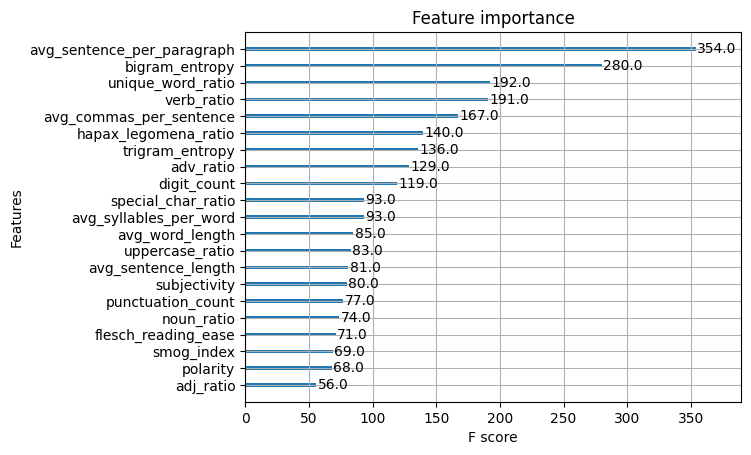

In [53]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Feature Importance Plot
import matplotlib.pyplot as plt
xgb.plot_importance(xgb_model)
plt.show()

In [ ]:
def cross_validate_xgboost(X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    accuracies = []

    for train_index, test_index in skf.split(X, y):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Initialize and train the model
        model = xgb.XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            use_label_encoder=False,
            n_estimators=100,
            max_depth=5,
            learning_rate=0.1
            )
        model.fit(X_train, y_train)

        # Make predictions
        y_probs = model.predict_proba(X_test)
        plt.hist(y_probs[:, 1], bins=20, alpha=0.7, color="blue", edgecolor="black")
        plt.xlabel("Probability of LLM-Generated")
        plt.ylabel("Frequency")
        plt.title("XGBoost Prediction Confidence")
        plt.show()
        # Compute accuracy
        acc = accuracy_score(y_test, y_pred)
        accuracies.append(acc)
        print(f"Fold Accuracy: {acc:.4f}")

    # Compute average accuracy
    #mean_acc = np.mean(accuracies)
    #print(f"\nAverage Accuracy over {n_splits}-fold CV: {mean_acc:.4f}")

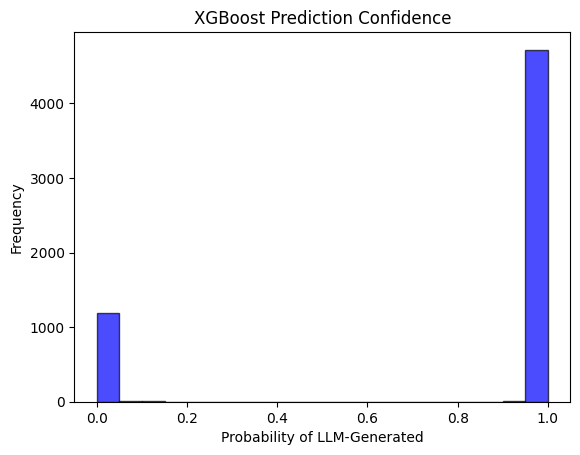

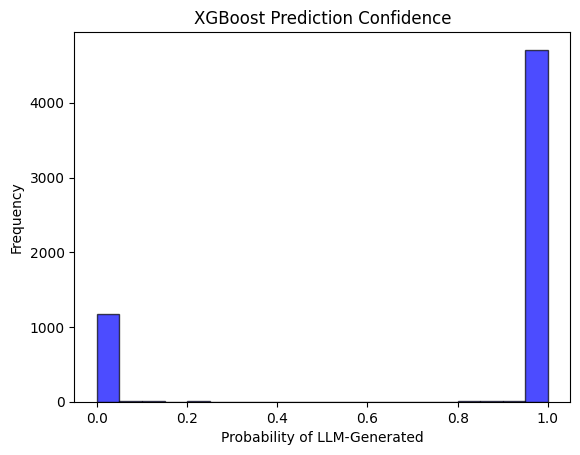

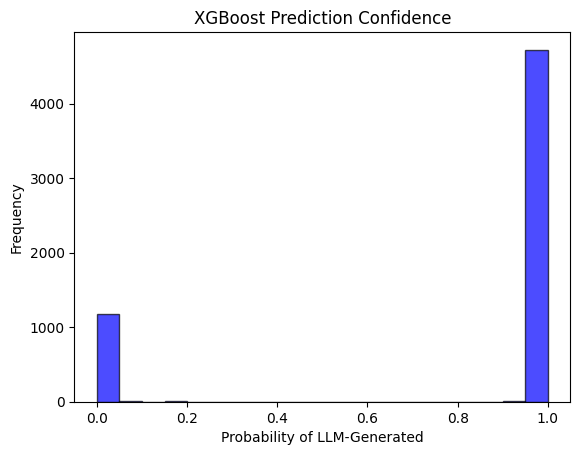

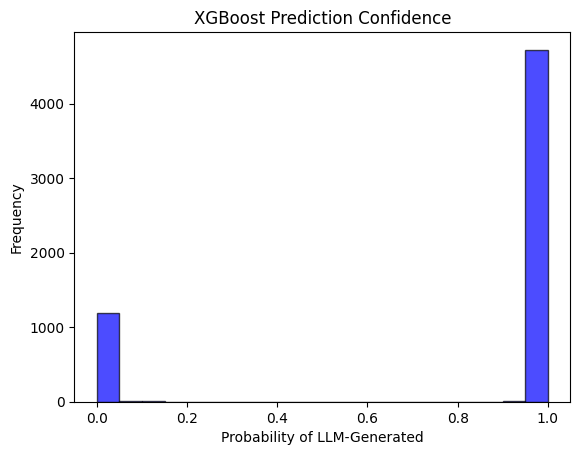

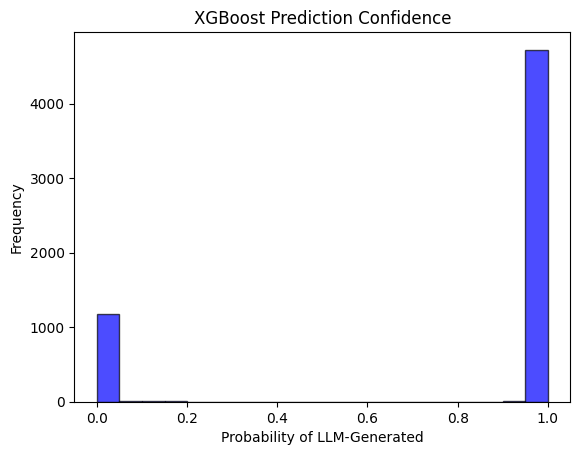

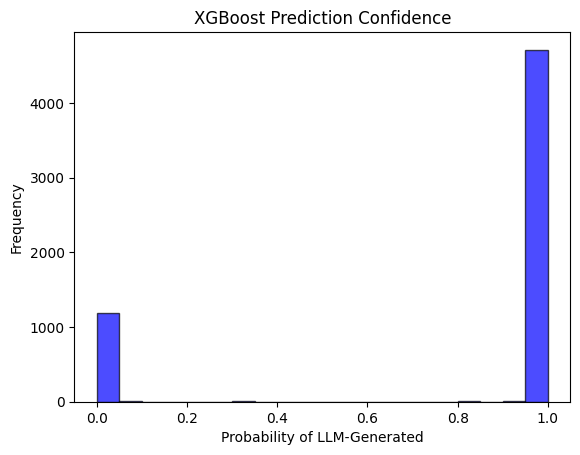

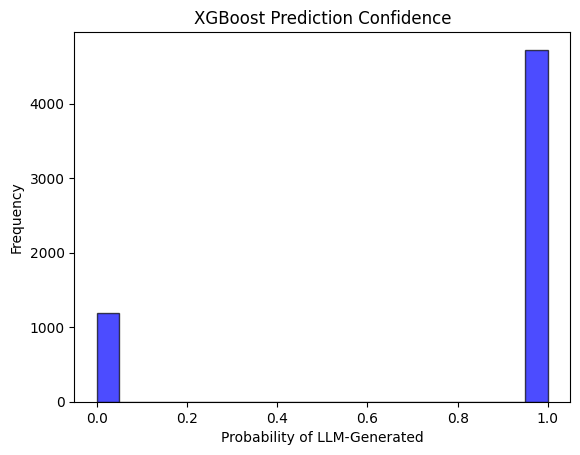

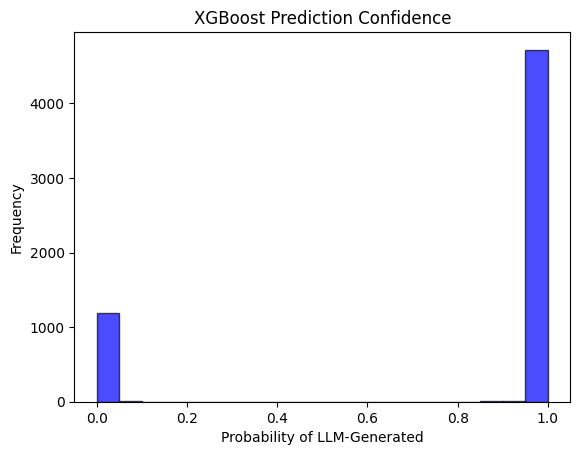

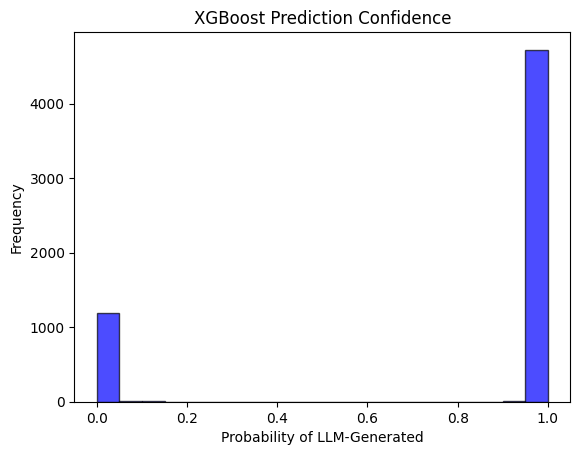

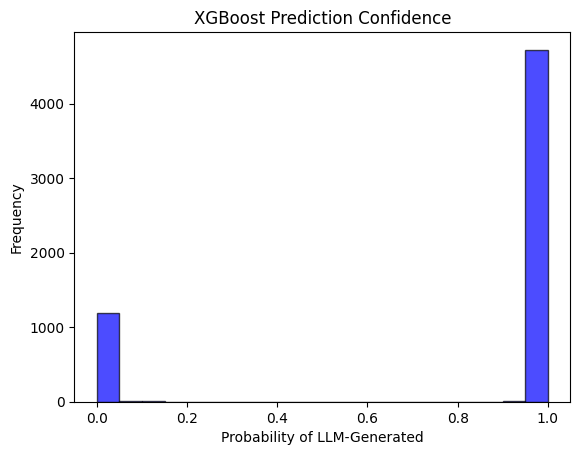

0        1
1        1
2        1
3        1
4        1
        ..
59321    0
59322    0
59323    0
59324    0
59325    0
Name: is_llm, Length: 59326, dtype: int32

In [ ]:
# TODO: train on some data that excludes what we predicted with binoculars. Then predict the same rows as binoculars and compare.
cross_validate_xgboost(X, y.astype(int), n_splits=10)
y.astype(int)

NameError: name 'y_probs' is not defined